# **LABORATORIO DE PROCESAMIENTO DIGITAL DE IMAGENES (PDI)**

Pablo Andres Villareal Cardenas - 2043233

Alan Zahir Lopez Rodriguez - 2103115


# **PRÁCTICA 4. *PROCESAMIENTO GEOMÉTRICO Y PROCESAMIENTO DE HISTOGRAMA***

---


**Importación de librerías y carga de las imágenes**

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen en escala de grises para parte 1 (procesamiento geométrico)
img_geo = cv2.imread('/content/rm.jpg', cv2.IMREAD_GRAYSCALE)

# Cargar la imagen en escala de grises para parte 2 (ecualización de histograma)
img_hist = cv2.imread('/content/radiografia.jpeg', cv2.IMREAD_GRAYSCALE)

> Se importan las librerías necesarias para la práctica: `cv2` (OpenCV) para las operaciones de procesamiento de imágenes, `numpy` para el manejo de matrices y `matplotlib.pyplot` para la visualización de resultados.

> Ambas imágenes médicas se cargan directamente en escala de grises mediante la bandera `cv2.IMREAD_GRAYSCALE`, ya que este tipo de imagenes médicas suelen representarse en un solo canal de intensidad, lo cual simplifica las transformaciones geométricas y el análisis de histograma que se realizarán más adelante.

# **Parte I. Procesamiento geométrico**

**Ejercicio 1. Traslación**

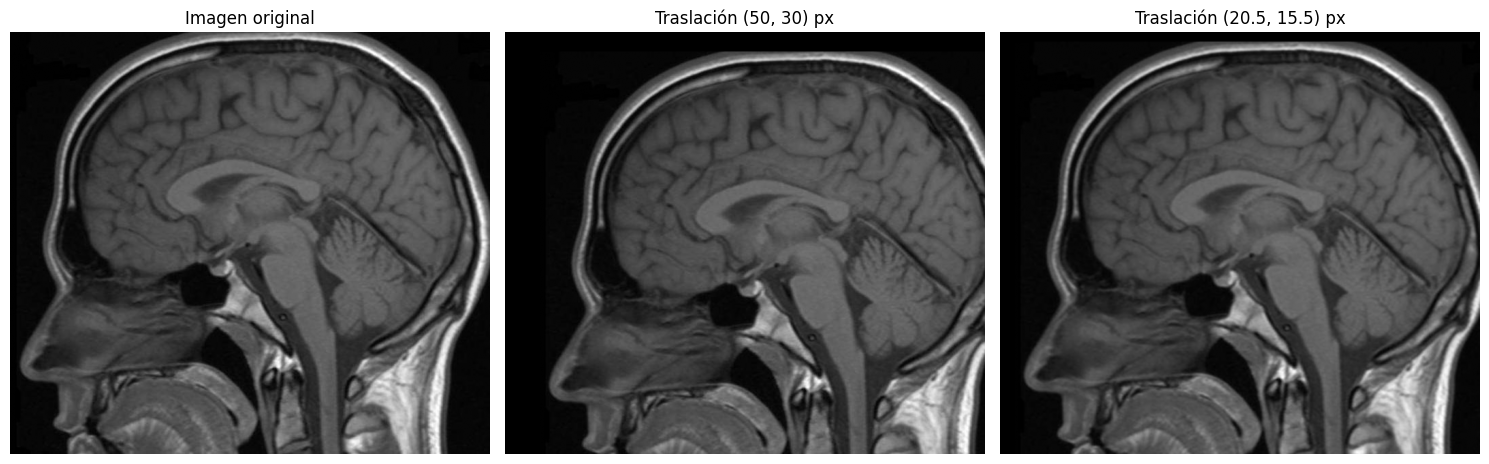

In [14]:
# Obtener las dimensiones (filas [h], columnas [w]) de la imagen
h, w = img_geo.shape

# Matriz de traslación con valores enteros (50, 30)
M_entera = np.float32([[1, 0, 50], [0, 1, 30]])
img_trasladada_entera = cv2.warpAffine(img_geo, M_entera, (w, h))

# Matriz de traslación con valores decimales (siguiendo el ejemplo de 20.5, 15.5 px)
M_decimal = np.float32([[1, 0, 20.5], [0, 1, 15.5]])
img_trasladada_decimal = cv2.warpAffine(img_geo, M_decimal, (w, h))

# Mostrar la imagen original y las dos imágenes trasladadas
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_geo, cmap='gray')
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_trasladada_entera, cmap='gray')
plt.title('Traslación (50, 30) px')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_trasladada_decimal, cmap='gray')
plt.title('Traslación (20.5, 15.5) px')
plt.axis('off')

# Ajustar y mostrar la figur
plt.tight_layout()
plt.show()

> Para trasladar la imagen se construyó la matriz de transformación que utiliza `cv2.warpAffine`, en donde los valores de la tercera columna (`tx`, `ty`) corresponden al desplazamiento en píxeles sobre los ejes X y Y respectivamente.

> En el primer caso se aplicó un desplazamiento de valores enteros (50, 30), mientras que en el segundo se utilizaron valores decimales (20.5, 15.5) sugeridos. La imagen trasladada de forma decimal presenta una suavización sutil en los bordes en comparación con la traslación entera debido a que open cv resuelve internamente los corrimientos sub pixel.

**Ejercicio 2. Rotación**

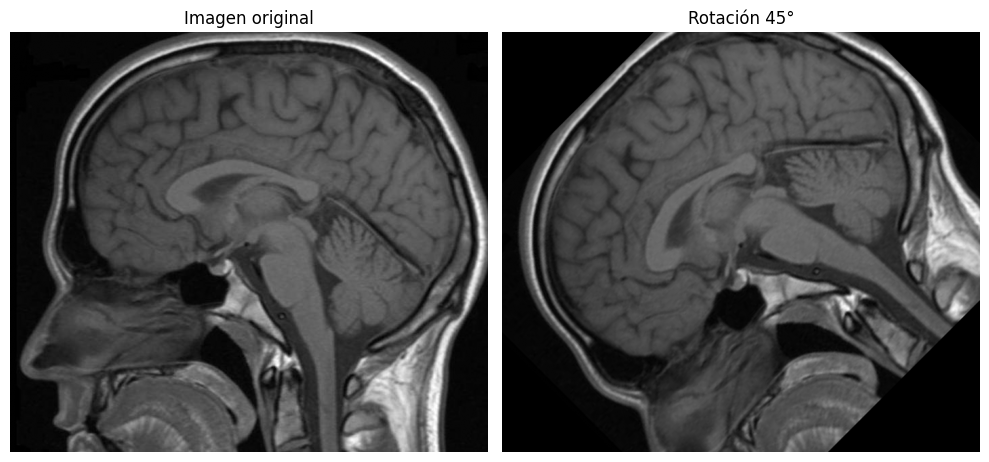

In [15]:
# Definir el centro de la imagen como punto de rotación
centro = (w // 2, h // 2)

# Obtener la matriz de rotación para un ángulo de 45° sin escalado adicional
M_rotacion = cv2.getRotationMatrix2D(centro, 45, 1.0)

# Aplicar la rotación a la imagen
img_rotada = cv2.warpAffine(img_geo, M_rotacion, (w, h))

# Mostrar la imagen original y la imagen rotada
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_geo, cmap='gray')
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_rotada, cmap='gray')
plt.title('Rotación 45°')
plt.axis('off')

plt.tight_layout()
plt.show()

> La rotación se calculó con `cv2.getRotationMatrix2D`, indicando como punto de pivote el centro geométrico de la imagen (`w // 2`, `h // 2`), un ángulo de 45° y un factor de escala de 1.0 (sin modificar el tamaño). Esta función devuelve la matriz de transformación afín correspondiente, la cual se aplica posteriormente con `cv2.warpAffine`.

> Al rotar sobre el centro y mantener el mismo tamaño de lienzo (`w`, `h`), las esquinas de la imagen original quedan recortadas en la imagen resultante, ya que el área rotada excede el marco original.

**Ejercicio 3. Escala**

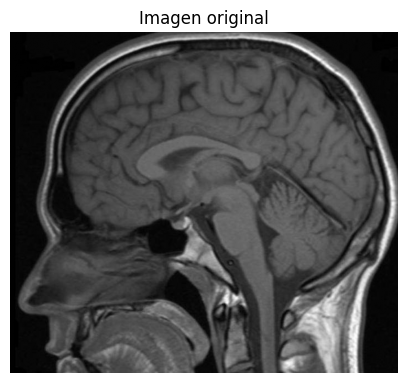

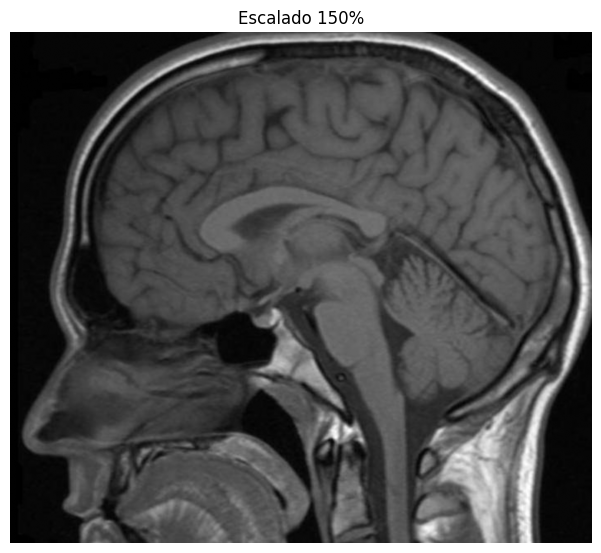

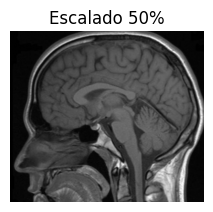

In [29]:
# Escalar al 150% (x1.5)
img_escalada_150 = cv2.resize(img_geo, (int(w * 1.5), int(h * 1.5)), interpolation=cv2.INTER_LINEAR)

# Escalar al 50% (x0.5)
img_escalada_50 = cv2.resize(img_geo, (int(w * 0.5), int(h * 0.5)), interpolation=cv2.INTER_LINEAR)

# Mostrar la imagen original
plt.figure(figsize=(5, 5))
plt.imshow(img_geo, cmap='gray')
plt.title('Imagen original')
plt.axis('off')
plt.show()

# Mostrar la imagen al 150%
plt.figure(figsize=(7.5, 7.5))
plt.imshow(img_escalada_150, cmap='gray')
plt.title('Escalado 150%')
plt.axis('off')
plt.show()

# Mostrar la imagen al 50%
plt.figure(figsize=(2.5, 2.5))
plt.imshow(img_escalada_50, cmap='gray')
plt.title('Escalado 50%')
plt.axis('off')
plt.show()

> El escalado se realizó con `cv2.resize`, indicando el escalado directamente en la función. Tanto para el aumento de tamaño (150%) como para la reducción (50%) se utilizó el método de interpolación bilineal (`cv2.INTER_LINEAR`).

# **Parte II. Ecualización de histograma**

**Ejercicio 1. Ecualización de histograma**

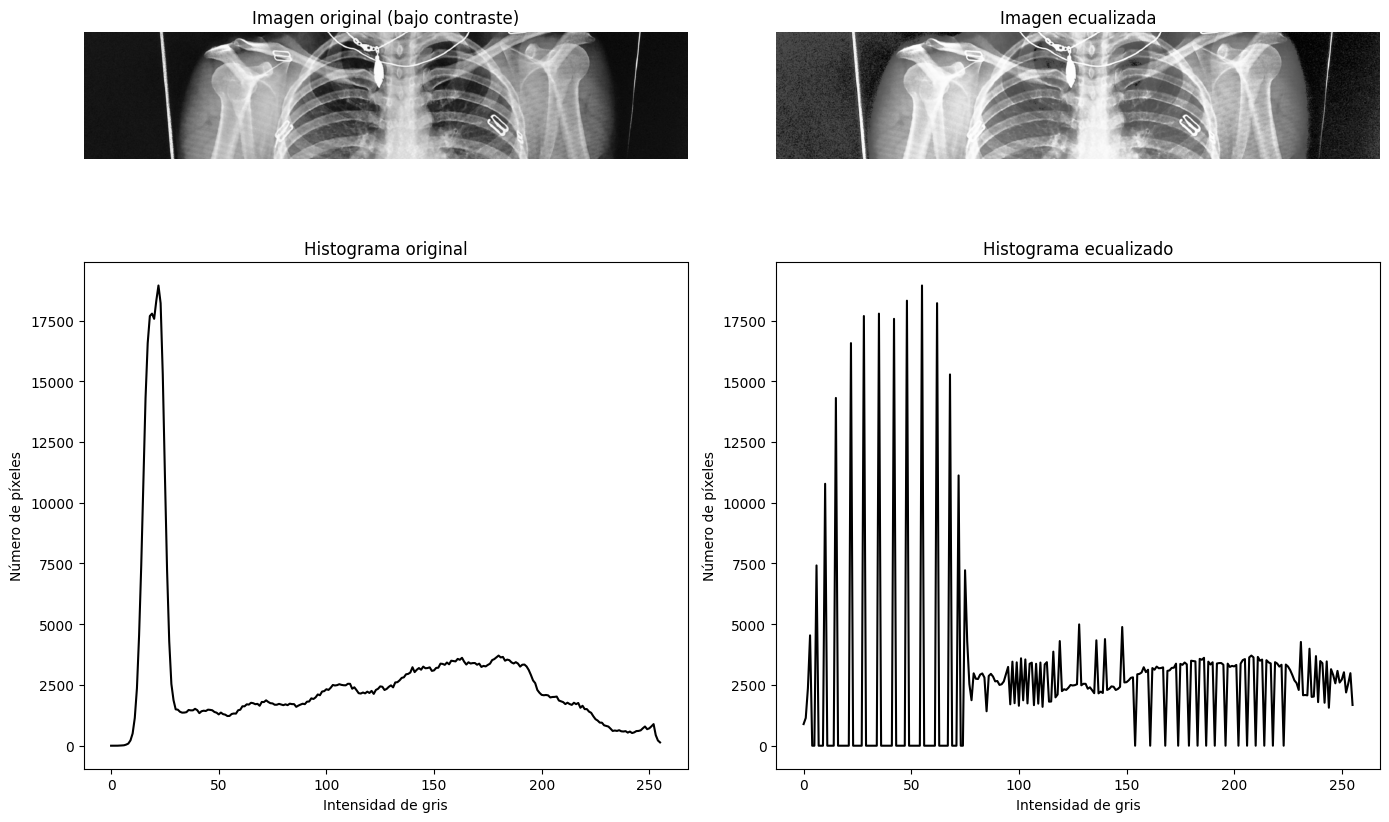

In [27]:
# Obtener el histograma de la imagen de bajo contraste
hist = cv2.calcHist([img_hist], [0], None, [256], [0, 256])

# Ecualizar histograma para mejorar el contraste
img_ecualizada = cv2.equalizeHist(img_hist)

# Calcular el histograma de la imagen ya ecualizada
hist_ecualizado = cv2.calcHist([img_ecualizada], [0], None, [256], [0, 256])

# Mostrar imagen original, imagen ecualizada y ambos histogramas
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(img_hist, cmap='gray')
plt.title('Imagen original (bajo contraste)')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_ecualizada, cmap='gray')
plt.title('Imagen ecualizada')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.plot(hist, color='black')
plt.title('Histograma original')
plt.xlabel('Intensidad de gris')
plt.ylabel('Número de píxeles')

plt.subplot(2, 2, 4)
plt.plot(hist_ecualizado, color='black')
plt.title('Histograma ecualizado')
plt.xlabel('Intensidad de gris')
plt.ylabel('Número de píxeles')

plt.tight_layout()
plt.show()

> Primero se obtuvo el histograma de la imagen original mediante `cv2.calcHist`, especificando canal único (`[0]`), sin máscara, con intensidad del 0 al 255. En este histograma se observa que los valores de intensidad de la imagen original están concentrados en un rango reducido, lo cual se refleja visualmente como una imagen de bajo contraste.

> Después se aplicó `cv2.equalizeHist`, función que redistribuye los niveles de intensidad de la imagen de manera que el histograma resultante se aproxime a una distribución uniforme. Al comparar ambos histogramas, se aprecia cómo la ecualización expande el rango dinámico de la imagen, distribuyendo la información en todo el espectro de 0-255 lo que hace una mejoraría visible en el contraste de la imagen médica.